In [2]:
# use dfngp_env
import torch
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
# for reading HDF5 files
import h5py

In [3]:
# import region bounds
from regions import ROSS_BOUNDS

# assign region bounds
x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

## ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5

Description:   
Average basal melt rates for Antarctic ice shelves for the 2010–2018 period at high spatial resolution, estimated using CryoSat-2 data. Interpolated values in regions with missing data are provided as a separate field. We are currently working on using ICESat-2 data to improve the estimates over regions with missing CryoSat-2 data.

Repository with preprocessing:  
https://github.com/sioglaciology/ice_shelf_change

## Units

| Field    | Description                                                                           |
| -------- | ------------------------------------------------------------------------------------- |
| `time`   | 2010–2018 average                                                               |
| `x`, `y` | Already in Antarctic Polar Stereographic Projection [EPSG:3031](https://epsg.io/3031) |
| `smb`    | **mm i.e. per year** (ice equivalent i.e., as stated in Fig. 1 in paper)                                                                  |

In [4]:
# Specify your local path to the HDF5 file
path_to_file = "/home/kim/data/adusumulli/ANT_iceshelf_melt_rates_CS2_2010-2018_v0.h5"

adusumulli_bmb = h5py.File(path_to_file,'r')

## Make tensor

In [5]:
# Read arrays
# (10941, 1)
x = np.array(adusumulli_bmb["/x"])
# (10229, 1)
y = np.array(adusumulli_bmb["/y"]) 
# (10229, 10941) (ny, nx)
# NOTE: negate to turn basal melt rate into bmb (sign convention flip)
bmb = - np.array(adusumulli_bmb["/w_b"])

# Convert to torch, squeezing dims
x_t = torch.as_tensor(x.squeeze(), dtype = torch.float32)
y_t = torch.as_tensor(y.squeeze(), dtype = torch.float32)
bmb_t = torch.as_tensor(bmb, dtype = torch.float32)

# Meshgrid that matches raster layout (ny, nx)
Y, X = torch.meshgrid(y_t, x_t, indexing = "ij")

# (3, ny, nx)
bmb_tensor = torch.stack([X, Y, bmb_t], dim = 0)

# Subset Ross region

In [6]:
# indices inside bounds
ix = torch.where((x_t >= x_min) & (x_t <= x_max))[0]
iy = torch.where((y_t >= y_min) & (y_t <= y_max))[0]
bmb_ross = bmb_tensor[:, iy[0] : iy[-1] + 1, ix[0] : ix[-1] + 1]

# Visualise data

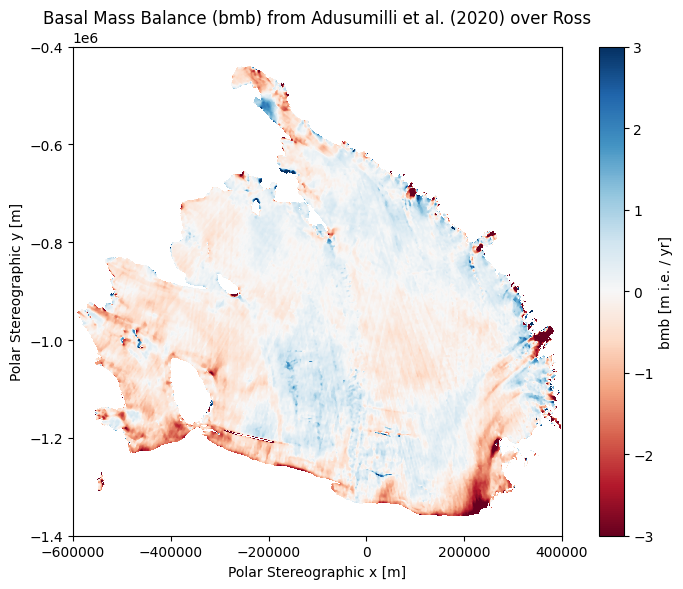

In [7]:
plt.figure(figsize = (8, 6))
pcm = plt.pcolormesh(
    bmb_ross[0],
    bmb_ross[1],
    bmb_ross[2], 
    cmap = "RdBu",
    vmax = 3.0,
    vmin = - 3.0
)
plt.colorbar(pcm, label = "bmb [m i.e. / yr]")
plt.title("Basal Mass Balance (bmb) from Adusumilli et al. (2020) over Ross")
plt.xlabel("Polar Stereographic x [m]")
plt.ylabel("Polar Stereographic y [m]")
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpolate at target grid